# Football players
## Topic and research questions:
This dataset provides detailed information about football players, including their physical attributes, personal information, skills, wages, clubs, and the date they joined their clubs. Using this data, it is possible to determine the market value, potential, and performance of each athlete. This information influences decisions regarding the renewal, signing, or cancellation of contracts with organizations or football clubs that may work with the athletes.

Research questions:

1. How does a player's popularity impact their market value and release clause?
2. Which stats (Attacking Skills and Goalkeeping Skills) have the biggest effects on a player's market value and pay, and how do these effects differ depending on the player's position?
3. What effects does age have on a player's performance (rating, skill attributes)?

This information will help football clubs identify players who fit their tactics and strategy. For coaches, it assists in improving team playmaking and formation. Players can identify their weaknesses and work on improving their skills, which in turn helps increase their market value.

## Data description:
The data selected is from the publicly available dataset titled "Player Score Regression." It was downloaded from the Sofifa website, located at the URL: https://sofifa.com/players. The dataset includes attributes for 18,979 football players. The provided dataset indicates that each player has about 77 attributes. These attributes include financial information (wage, market value, etc.), skill evaluations (dribbling, passing), physical characteristics (height, weight), and personal details (full name, date of birth), amounting to a total of 1,461,383 data points.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import numpy as np

In [2]:
# read csv file
scores = pd.read_csv('player_score_regression.csv')
scores.head()

/var/folders/0_/514klw2d5zs7kmfjt5s790tc0000gn/T/ipykernel_7557/3987232162.py:2: DtypeWarning: Columns (77) have mixed types. Specify dtype option on import or set low_memory=False.
  scores = pd.read_csv('player_score_regression.csv')


,Unnamed: 0,PlayerID,PlayerName,FullName,PhotoURL,PlayerURL,Country,Age,Rating in Scale 100,Potential in Scale 100,...,AttackingWorkRate,DefensiveWorkRate,InternationalReputation,Pace,Shooting,Passing,Dribbling.1,Defending,Physical,PopularityHits
0,0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,...,High,Low,5 ★,89,93,81,89,35,77,562
2,2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,...,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,...,High,High,4 ★,76,86,93,88,64,78,207
4,4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,...,High,Medium,5 ★,91,85,86,94,36,59,595


In [5]:
# Find every integer type columns and check its outliers. 
scores.describe()

,Unnamed: 0,PlayerID,Age,Rating in Scale 100,Potential in Scale 100,BestOverall,AttackingSkills,CrossingAbility,FinishingAbility,HeadingAccuracy,...,GoalkeeperKicking,GoalkeeperPositioning,GoalkeeperReflexes,TotalStats,BaseStats,Pace,Passing,Dribbling.1,Defending,Physical
count,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,...,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000
mean,9489.000000,226403.384794,25.194109,72.294694,78.255177,66.751726,248.938142,49.688392,45.842405,51.942726,...,16.076453,16.217187,16.519627,1595.286949,355.702197,67.453975,57.681016,62.875020,49.866221,64.368934
std,5478.909715,27141.054157,4.710520,21.287187,22.492562,6.747193,74.299428,18.131153,19.567081,17.294409,...,16.491103,17.002239,17.854079,269.874789,40.761117,10.677859,10.081857,9.927415,16.443213,9.601883
min,0.000000,41.000000,16.000000,47.000000,47.000000,48.000000,42.000000,6.000000,3.000000,5.000000,...,2.000000,2.000000,2.000000,747.000000,232.000000,25.000000,25.000000,25.000000,12.000000,28.000000
25%,4744.500000,210135.000000,21.000000,62.000000,67.000000,62.000000,222.000000,38.000000,30.000000,44.000000,...,8.000000,8.000000,8.000000,1452.000000,327.000000,61.000000,51.000000,57.000000,35.000000,58.000000
50%,9489.000000,232418.000000,25.000000,67.000000,72.000000,67.000000,263.000000,54.000000,49.000000,55.000000,...,11.000000,11.000000,11.000000,1627.000000,356.000000,68.000000,58.000000,64.000000,53.000000,65.000000
75%,14233.500000,246922.500000,29.000000,72.000000,77.000000,71.000000,297.000000,63.000000,62.000000,64.000000,...,14.000000,14.000000,14.000000,1781.000000,384.000000,75.000000,64.000000,69.000000,63.000000,71.000000
max,18978.000000,259216.000000,53.000000,176.000000,180.000000,93.000000,437.000000,94.000000,95.000000,93.000000,...,93.000000,91.000000,90.000000,2316.000000,498.000000,96.000000,93.000000,95.000000,91.000000,91.000000


In [7]:
# find every columns type and check whether it in correct value type. 
scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 78 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               18979 non-null  int64 
 1   PlayerID                 18979 non-null  int64 
 2   PlayerName               18979 non-null  object
 3   FullName                 18979 non-null  object
 4   PhotoURL                 18979 non-null  object
 5   PlayerURL                18979 non-null  object
 6   Country                  18979 non-null  object
 7   Age                      18979 non-null  int64 
 8   Rating in Scale 100      18979 non-null  int64 
 9   Potential in Scale 100   18979 non-null  int64 
 10  CurrentClub              18979 non-null  object
 11  ContractInfo             18979 non-null  object
 12  PlayingPositions         18979 non-null  object
 13  Height                   18979 non-null  object
 14  Weight                   18979 non-nul

# Handling problem and cleaning
When analysing the dataset I found some problems.
1. In columns "Rating in Scale 100", "Potential in Scale 100" some values where more 100.
2. In column "International Reputation" 6 unique value instead of 5 (from 5★ to 1★).
3. "Popularity Hits" some values are not integer and have NaN values.
4. "Shooting" most values are integer but some values have string type.
5. Drop unnecessary columns that I'm not using for my research question.

In [9]:
# changing all cells that values is over 100 
def find_ratings_over_100(rating):
    if rating > 100:
        return rating - 100
    else:
        return rating

# Apply the function to the 'Rating in Scale 100' column
scores['Rating in Scale 100'] = scores['Rating in Scale 100'].apply(find_ratings_over_100)
# changing all cells that values is over 100 in 'Potential in Scale 100'
scores['Potential in Scale 100'] = scores['Potential in Scale 100'].apply(find_ratings_over_100)

In [11]:
# Find all null values in percentage. This step helps to drop unecessary columns.
null_columns=scores.columns[scores.isnull().any()]
scores[null_columns].isnull().sum()/len(scores)*100 

LoanEndDate       94.662522
PopularityHits    13.673007
dtype: float64

In [13]:
# in this column they have integer, str and Nan values that mixed, but most values are integer. Convert this column to int.
#If an error occurs during the converting process, data that cannot be converted will be deleted and dropped, 
#because these data cannot be recovered and unuseful.
scores['PopularityHits'] = pd.to_numeric(scores['PopularityHits'], errors='coerce')
scores = scores.dropna(subset=['PopularityHits'])
scores['PopularityHits'] = scores['PopularityHits'].astype(int)

In [15]:
#'InternationalReputation' have 6 unique values, find every value that not in valid_reputaionand and delete that rows. 
#We can't use 0 values in our research, because these data cannot be recovered and unuseful.
valid_reputations = {'5 ★', '4 ★', '3 ★', '2 ★', '1 ★'}
scores = scores[scores['InternationalReputation'].isin(valid_reputations)]

In [17]:
# My research question mainly focuses on market value. That's why players without market value can't be used.
# this rows will be dropped from final 
scores = scores[scores['MarketValue'] != '€0']

1. For my research question columns(FullName, PhotoURL, PlayerURL, Height, Weight,Country, CurrentClub, ContractInfo, PlayingPositions, PreferredFoot, DateJoined, LoanEndDate) not used, because this values are not have direct effect on my research.
2. The sum of this columns(CrossingAbility, FinishingAbility, HeadingAccuracy, ShortPassing, Volleys) is AttackingSkills that's why dropping this colums will not effect on my research.
3. The sum of this columns(Dribbling, CurveAbility, FreeKickAccuracy, LongPassing, BallControl) is SkillAttributes that's why dropping this colums will not effect on my research.
4. The sum of this columns(Acceleration, SprintSpeed, Agility, Reactions, Balance) is MovementSkills that's why dropping this colums will not effect on my research.
5. The sum of this columns(ShotPower, JumpingAbility, Stamina, Strength, LongShots) is PowerSkills that's why dropping this colums will not effect on my research.
6. The sum of this columns(Marking, StandingTackle, SlidingTackle) is DefendingSkills that's why dropping this colums will not effect on my research.
7. The sum of this columns(GoalkeeperDiving, GoalkeeperHandling, GoalkeeperKicking, GoalkeeperPositioning, GoalkeeperReflexes) is GoalkeepingSkill that's why dropping this colums will not effect on my research.
8. The sum of this columns(Pace, Shooting, Dribbling, Defending, Physical) is BaseStats that's why dropping this colums will not effect on my research.

In [19]:
columns_to_drop = ['Unnamed: 0','FullName','PhotoURL','PlayerURL','Country','CurrentClub','ContractInfo','PlayingPositions',
                   'PreferredFoot','DateJoined','LoanEndDate','CrossingAbility','FinishingAbility','HeadingAccuracy',
                   'ShortPassing','Volleys','Dribbling','CurveAbility','FreeKickAccuracy','LongPassing','BallControl',
                   'Acceleration','SprintSpeed','Agility','Reactions','Balance','ShotPower','JumpingAbility','Stamina',
                   'Strength','LongShots','Aggression','Interceptions','Positioning','Vision','Penalties','Composure',
                   'Marking','StandingTackle','SlidingTackle','GoalkeeperDiving','GoalkeeperHandling','GoalkeeperKicking',
                   'GoalkeeperPositioning','GoalkeeperReflexes','Pace','Passing','Shooting','Dribbling.1','Defending','Physical','Height','Weight']
scores = scores.drop(columns=columns_to_drop)

In [21]:
# After dropping all values that I'm not using. Check if there is a outlier values.
scores.describe()

,PlayerID,Age,Rating in Scale 100,Potential in Scale 100,BestOverall,AttackingSkills,SkillAttributes,MovementSkills,PowerSkills,MentalAttributes,DefendingSkills,GoalkeepingSkills,TotalStats,BaseStats,PopularityHits
count,16110.000000,16110.000000,16110.000000,16110.000000,16110.000000,16110.000000,16110.000000,16110.000000,16110.000000,16110.000000,16110.000000,16110.000000,16110.000000,16110.000000,16110.000000
mean,222823.723277,25.865860,64.161701,69.097952,68.394289,257.730478,265.726071,322.957356,304.544134,262.514215,144.817318,80.465736,1638.755307,364.306145,22.931657
std,26969.724404,4.466699,11.760448,10.606019,5.538591,71.940404,76.356857,53.918797,47.679485,62.010428,61.130904,84.900395,250.662890,35.837341,63.227578
min,41.000000,16.000000,16.000000,18.000000,58.000000,42.000000,43.000000,124.000000,122.000000,51.000000,20.000000,10.000000,823.000000,252.000000,1.000000
25%,206010.000000,22.000000,62.000000,66.000000,64.000000,235.000000,235.000000,295.000000,277.000000,239.000000,88.000000,48.000000,1519.250000,339.000000,2.000000
50%,228723.000000,26.000000,66.000000,71.000000,68.000000,272.000000,280.000000,332.000000,310.000000,271.000000,169.000000,53.000000,1668.000000,363.000000,5.000000
75%,242684.750000,29.000000,70.000000,75.000000,72.000000,303.000000,316.000000,360.000000,339.000000,302.000000,194.000000,59.000000,1804.000000,388.000000,15.000000
max,259214.000000,43.000000,93.000000,93.000000,93.000000,437.000000,470.000000,464.000000,444.000000,421.000000,272.000000,440.000000,2316.000000,498.000000,979.000000


In [23]:
# download clean dataset
scores.to_csv('A1_CleanDataset.csv')

# Analysing the data 

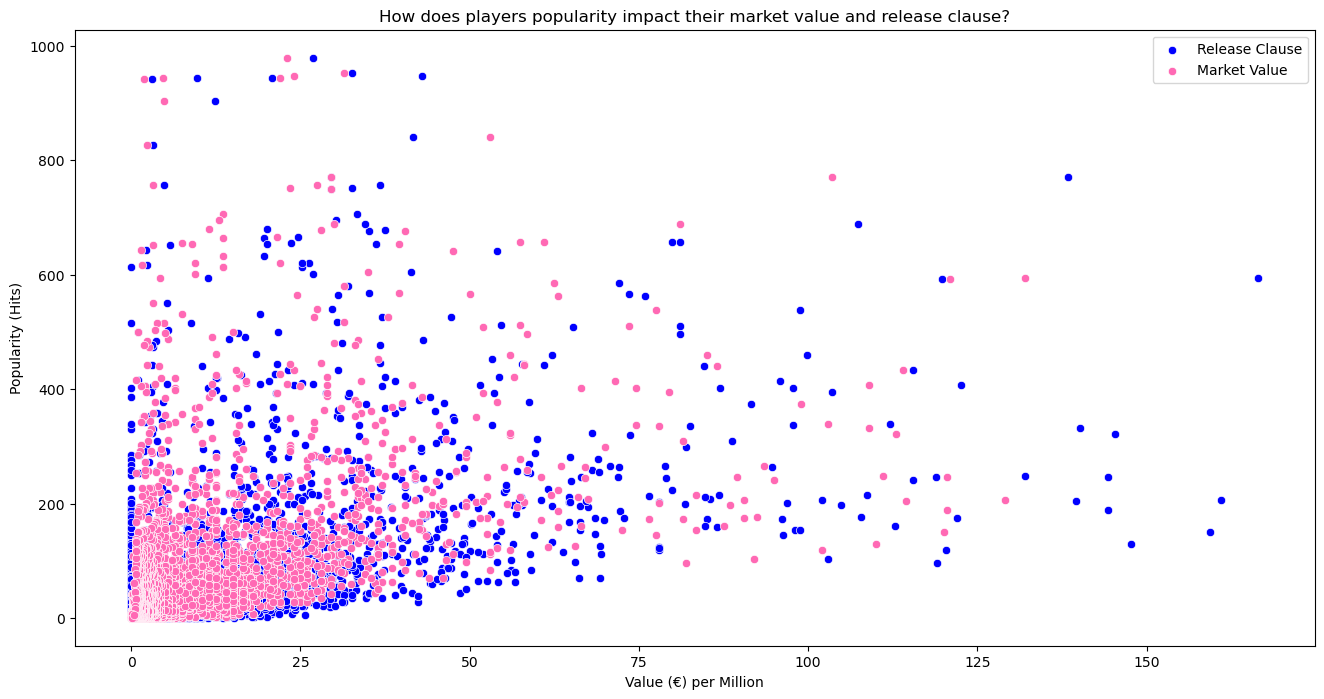

In [25]:
# to find popularity impact on market valuem release clause. I used 'Popularity Hits', 'MarketValue'and 'Release clause' columns.
# 'MarketValue'and 'Release clause' are string values, to get float values i created process_value() function that return it's float values.
# after this all processed values are stored in 'ProcessedMarketValue' and 'ProcessedReleaseClause'
def process_value(value):
    if 'M' in value:
        return float(value.replace('€', '').replace('M', ''))
    elif value == '€0':
        return 0
    else:
        return float(value.replace('€', '').replace('K', ''))/1000
        
scores['ProcessedMarketValue'] = scores['MarketValue'].apply(process_value)
scores['ProcessedReleaseClause'] = scores['ReleaseClause'].apply(process_value)

plt.figure(figsize=(16, 8)) 
sns.scatterplot(x='ProcessedReleaseClause', y='PopularityHits', data=scores, label='Release Clause', color='blue')
sns.scatterplot(x='ProcessedMarketValue', y='PopularityHits', data=scores, label='Market Value', color='hotpink')
plt.title('How does players popularity impact their market value and release clause?')
plt.ylabel('Popularity (Hits)')
plt.xlabel('Value (€) per Million')
plt.legend()
plt.show()

Text(0, 0.5, 'Position')

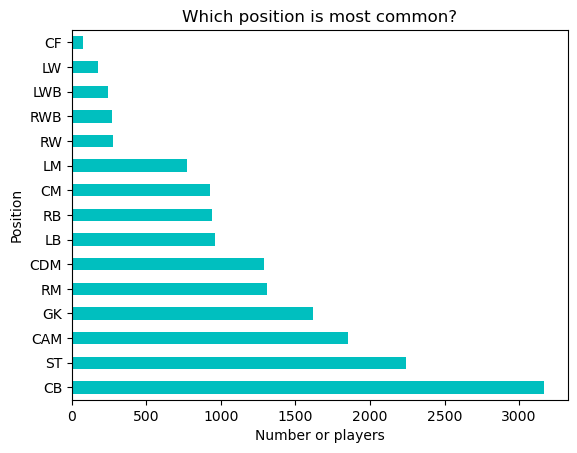

In [27]:
# find most common position
players_position_freq = scores['BestPosition'].value_counts()
x = players_position_freq.plot.barh(title='Which position is most common?', color = 'c')
x.set_xlabel('Number or players')
x.set_ylabel('Position')

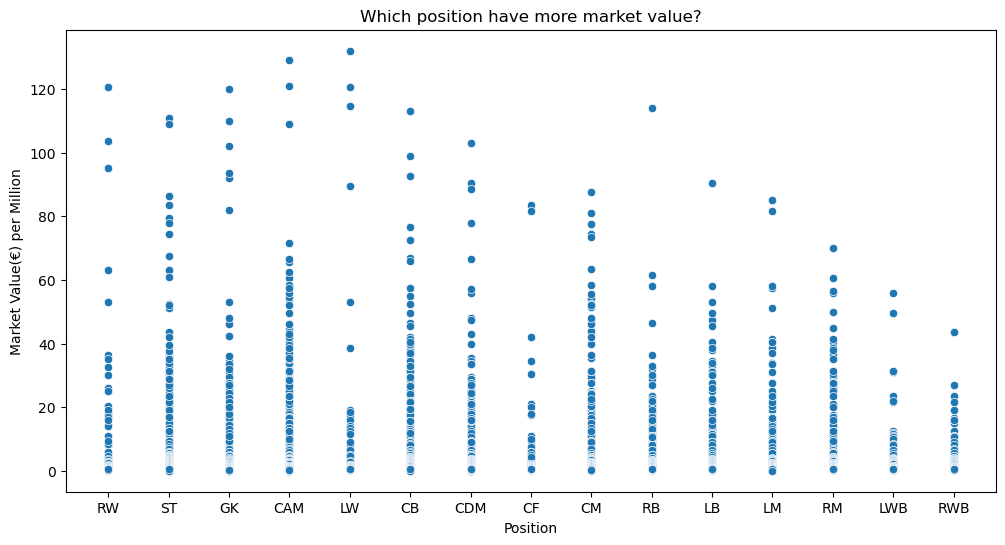

In [29]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='BestPosition', y='ProcessedMarketValue', data=scores)
plt.title('Which position have more market value?')
plt.xlabel('Position')
plt.ylabel('Market Value(€) per Million')
plt.show()

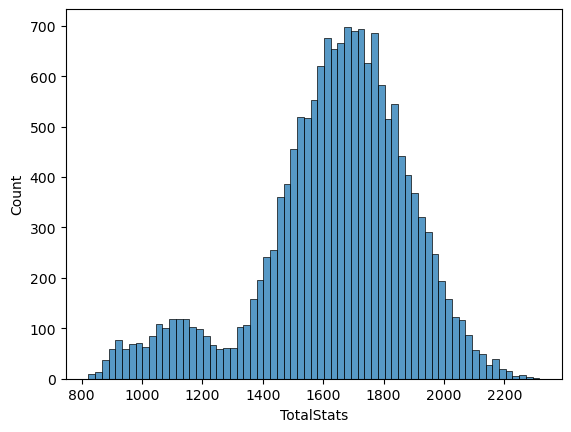

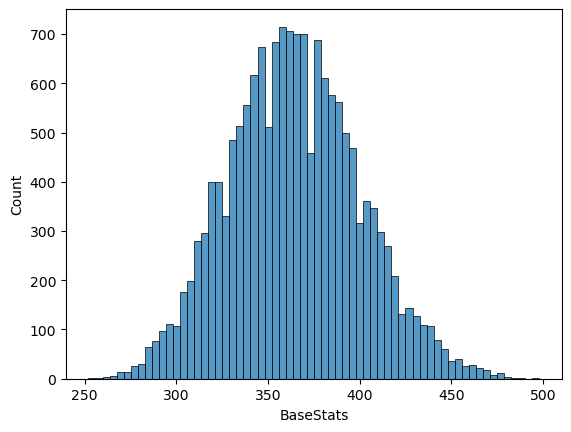

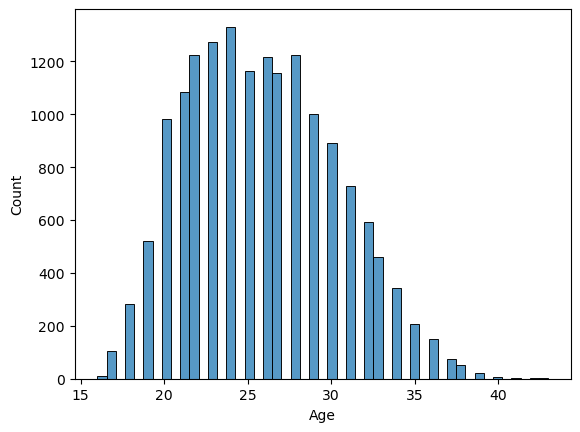

In [31]:
ls=['TotalStats', 'BaseStats', 'Age']

for val in ls: 
    sns.histplot(scores[val])
    plt.show()

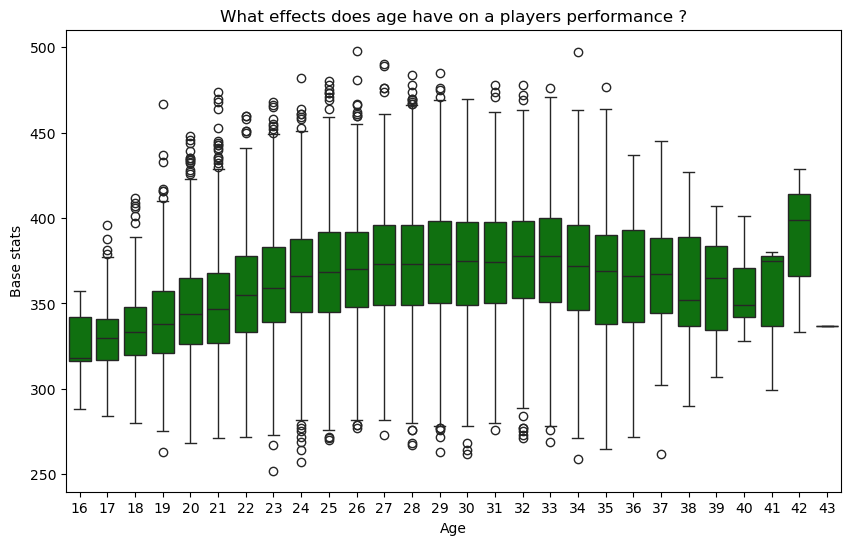

In [33]:
plt.figure(figsize=(10, 6)) 
sns.boxplot(x='Age', y='BaseStats', data=scores, color='g')
plt.title('What effects does age have on a players performance ?')
plt.xlabel('Age')
plt.ylabel('Base stats')
plt.show()

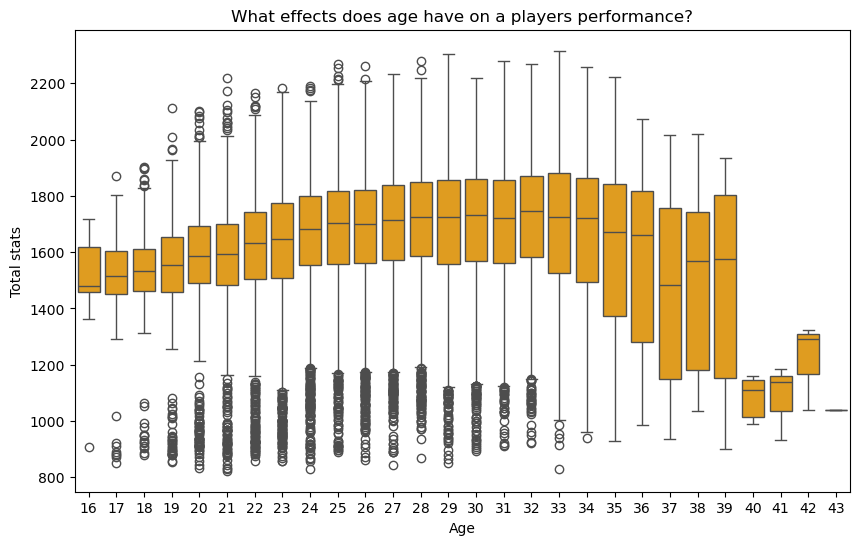

In [35]:
plt.figure(figsize=(10, 6)) 
sns.boxplot(x='Age', y='TotalStats', data=scores, color='orange')
plt.title('What effects does age have on a players performance?')
plt.xlabel('Age')
plt.ylabel('Total stats')
plt.show()

In [37]:
# after cleaning process there is no null or missing values
null_columns=scores.columns[scores.isnull().any()]
scores[null_columns].isnull().sum()/len(scores)*100 

Series([], dtype: float64)

In [39]:
# after cleaning there is 16110 rows
len(scores)

16110